SKILL- 7

Data loading and preprocessing on project datset using pytorch

\ Dataset found at: /content/plant-seedlings-dataset
Classes found: ['test', 'train']
\ Training samples: 4435
\ Validation samples: 1109
Epoch [1/10] - Train Loss: 0.4472, Val Loss: 0.4092, Accuracy: 85.57%
Epoch [2/10] - Train Loss: 0.4034, Val Loss: 0.3947, Accuracy: 85.57%
Epoch [3/10] - Train Loss: 0.3988, Val Loss: 0.3995, Accuracy: 85.57%
Epoch [4/10] - Train Loss: 0.3896, Val Loss: 0.3837, Accuracy: 85.57%
Epoch [5/10] - Train Loss: 0.3820, Val Loss: 0.3842, Accuracy: 85.57%
Epoch [6/10] - Train Loss: 0.3654, Val Loss: 0.3716, Accuracy: 85.57%
Epoch [7/10] - Train Loss: 0.3363, Val Loss: 0.3492, Accuracy: 85.57%
Epoch [8/10] - Train Loss: 0.2829, Val Loss: 0.3445, Accuracy: 84.13%
Epoch [9/10] - Train Loss: 0.2389, Val Loss: 0.4136, Accuracy: 85.21%
Epoch [10/10] - Train Loss: 0.2010, Val Loss: 0.4736, Accuracy: 84.49%
\ Model saved successfully!


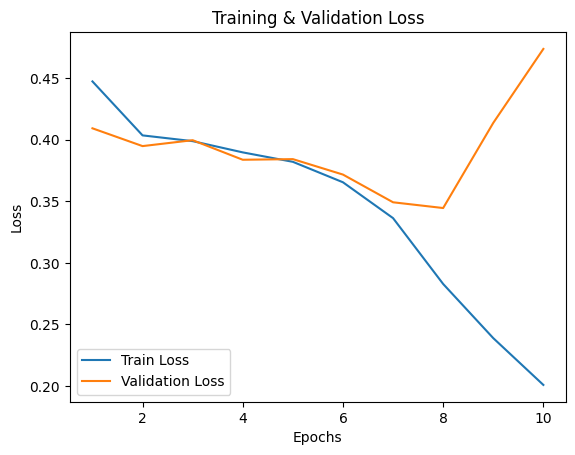

\ Model loaded successfully!


FileNotFoundError: [Errno 2] No such file or directory: '/content/sample_plant.jpg'

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

dataset_path = "/content/plant-seedlings-dataset"

if not os.path.exists(dataset_path):
    print("\ Dataset path does not exist! Check extraction.")
else:
    print("\ Dataset found at:", dataset_path)

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = ImageFolder(root=dataset_path, transform=train_transforms)
num_classes = len(dataset.classes)
print(f"Classes found: {dataset.classes}")

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
val_dataset.dataset.transform = val_transforms

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"\ Training samples: {len(train_dataset)}")
print(f"\ Validation samples: {len(val_dataset)}")

class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        accuracy = 100 * correct / total
        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Accuracy: {accuracy:.2f}%")
    return train_losses, val_losses

epochs = 10
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, epochs)

torch.save(model.state_dict(), "plant_seedlings_cnn.pth")
print("\ Model saved successfully!")

plt.plot(range(1, epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, epochs+1), val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()

loaded_model = CNNModel(num_classes)
loaded_model.load_state_dict(torch.load("plant_seedlings_cnn.pth"))
loaded_model.to(device)
loaded_model.eval()
print("\ Model loaded successfully!")

def visualize_layer_outputs(model, image_path, transform):
    image = Image.open(image_path)
    image = transform(image).unsqueeze(0).to(device)
    model.eval()
    activations = []
    with torch.no_grad():
        x = image
        for layer in model.model:
            x = layer(x)
            if isinstance(layer, nn.ReLU):
                activations.append(x.cpu().numpy()[0])
    fig, axes = plt.subplots(1, len(activations), figsize=(15, 5))
    for i, activation in enumerate(activations):
        axes[i].imshow(np.mean(activation, axis=0), cmap='viridis')
        axes[i].axis("off")
    plt.show()

image_path = "/content/sample_plant.jpg"
visualize_layer_outputs(loaded_model, image_path, val_transforms)

In [ ]:
import os

zip_path = "/content/plant-seedlings-classification (1).zip"

if os.path.exists(zip_path):
    print(f"✅ File found: {zip_path}")
else:
    print("❌ File not found! Please upload it again.")

✅ File found: /content/plant-seedlings-classification (1).zip


In [ ]:
new_zip_path = "/content/plant-seedlings.zip"
os.rename(zip_path, new_zip_path)
print(f"✅ Renamed file to: {new_zip_path}")


✅ Renamed file to: /content/plant-seedlings.zip


In [ ]:
import zipfile

extract_path = "/content/plant-seedlings-dataset"

# Create the directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract the ZIP file
with zipfile.ZipFile(new_zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"✅ Extraction complete! Files are saved in: {extract_path}")

✅ Extraction complete! Files are saved in: /content/plant-seedlings-dataset


SKILL-8

Apply augmentation ,regularization, dropout and other parameter tuning techniques to the project   
data   for classification and compare the  result

 Dataset found at: /content/plant-seedlings-dataset
Classes found: ['test', 'train']
 Training samples: 4435
 Validation samples: 1109
Epoch [1/20] - Train Loss: 1.2911, Val Loss: 0.4238, Accuracy: 85.66%
Model Saved!
Epoch [2/20] - Train Loss: 0.4441, Val Loss: 0.4208, Accuracy: 85.66%
Model Saved!
Epoch [3/20] - Train Loss: 0.4454, Val Loss: 0.4251, Accuracy: 85.66%
Epoch [4/20] - Train Loss: 0.4318, Val Loss: 0.4000, Accuracy: 85.66%
Model Saved!
Epoch [5/20] - Train Loss: 0.4077, Val Loss: 0.4168, Accuracy: 85.66%
Epoch [6/20] - Train Loss: 0.3727, Val Loss: 0.4532, Accuracy: 85.66%
Epoch [7/20] - Train Loss: 0.3251, Val Loss: 0.3918, Accuracy: 85.66%
Model Saved!
Epoch [8/20] - Train Loss: 0.3112, Val Loss: 0.3718, Accuracy: 85.66%
Model Saved!
Epoch [9/20] - Train Loss: 0.3025, Val Loss: 1.0167, Accuracy: 85.66%
Epoch [10/20] - Train Loss: 0.2846, Val Loss: 0.2840, Accuracy: 85.66%
Model Saved!
Epoch [11/20] - Train Loss: 0.2913, Val Loss: 0.4370, Accuracy: 85.66%
Epoch [12/20] -

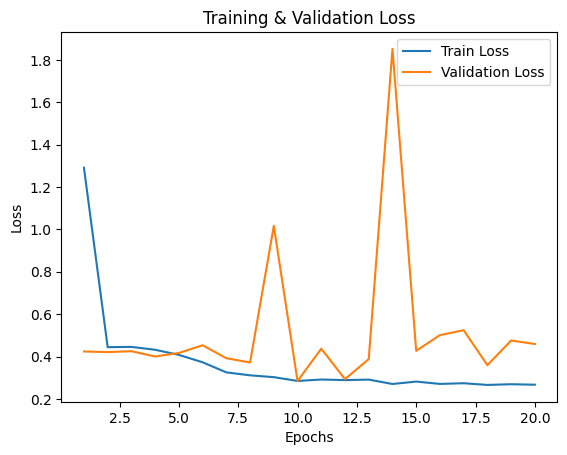

 Final Model Saved as final_model.pth


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import os
import matplotlib.pyplot as plt
import numpy as np


dataset_path = "/content/plant-seedlings-dataset"

if not os.path.exists(dataset_path):
    print(" Dataset path does not exist! Check extraction.")
else:
    print(" Dataset found at:", dataset_path)

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = ImageFolder(root=dataset_path, transform=train_transforms)
num_classes = len(dataset.classes)
print(f"Classes found: {dataset.classes}")

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
val_dataset.dataset.transform = val_transforms

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f" Training samples: {len(train_dataset)}")
print(f" Validation samples: {len(val_dataset)}")

class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.5),

            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=20):
    train_losses, val_losses = [], []
    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0.0
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        accuracy = 100 * correct / total

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Accuracy: {accuracy:.2f}%")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_model.pth')
            print("Model Saved!")

    return train_losses, val_losses

train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer)

plt.plot(range(1, 21), train_losses, label="Train Loss")
plt.plot(range(1, 21), val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()

torch.save(model.state_dict(), "final_model.pth")
print(" Final Model Saved as final_model.pth")

SKILL-9


Implement a  VGG , Alexnet model to classify   images  given in the project using suitable layers

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import torchvision.models as models
import os
import matplotlib.pyplot as plt

path = "/content/plant-seedlings-dataset"
if not os.path.exists(path):
    print(" Dataset not found!")
    exit()

transforms_ = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset = ImageFolder(root=path, transform=transforms_)
classes = len(dataset.classes)
train_size = int(0.8 * len(dataset))
train_ds, val_ds = random_split(dataset, [train_size, len(dataset) - train_size])
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

def get_model(model_type):
    model = getattr(models, model_type)(pretrained=True)
    model.classifier[6] = nn.Linear(4096, classes)
    return model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

def train(model, loader, val_loader, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    criterion, optimizer = nn.CrossEntropyLoss(), optim.Adam(model.parameters(), lr=0.0005)
    best_loss = float('inf')
    for epoch in range(epochs):
        model.train()
        loss_epoch = sum(criterion(model(img.to(device)), lbl.to(device)).item() for img, lbl in loader) / len(loader)
        model.eval()
        val_loss, correct = 0, 0
        with torch.no_grad():
            for img, lbl in val_loader:
                img, lbl = img.to(device), lbl.to(device)
                outputs = model(img)
                val_loss += criterion(outputs, lbl).item()
                correct += (outputs.argmax(1) == lbl).sum().item()
        val_loss /= len(val_loader)
        print(f"Epoch {epoch+1}: Train Loss: {loss_epoch:.4f}, Val Loss: {val_loss:.4f}, Accuracy: {100 * correct / len(val_ds):.2f}%")
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), 'alexnet_model.pth')
            print(" AlexNet Model Saved!")

print("Training AlexNet...")
train(get_model("alexnet"), train_loader, val_loader)


Training AlexNet...


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:01<00:00, 167MB/s]


Epoch 1: Train Loss: 0.9319, Val Loss: 0.9085, Accuracy: 22.27%
 AlexNet Model Saved!
Epoch 2: Train Loss: 0.9318, Val Loss: 0.9089, Accuracy: 24.08%
Epoch 3: Train Loss: 0.9295, Val Loss: 0.9009, Accuracy: 24.44%
 AlexNet Model Saved!
Epoch 4: Train Loss: 0.9340, Val Loss: 0.9024, Accuracy: 21.55%
Epoch 5: Train Loss: 0.9284, Val Loss: 0.9067, Accuracy: 22.81%
Epoch 6: Train Loss: 0.9262, Val Loss: 0.8991, Accuracy: 22.45%
 AlexNet Model Saved!
Epoch 7: Train Loss: 0.9321, Val Loss: 0.9032, Accuracy: 21.55%
Epoch 8: Train Loss: 0.9324, Val Loss: 0.9029, Accuracy: 22.81%
Epoch 9: Train Loss: 0.9343, Val Loss: 0.9066, Accuracy: 24.17%
Epoch 10: Train Loss: 0.9319, Val Loss: 0.9071, Accuracy: 22.27%


SKILL- 10


Create a Recurrent neural network   to classify given Project   data

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import os
import matplotlib.pyplot as plt

path = "/content/plant-seedlings-dataset"
if not os.path.exists(path):
    print("Dataset not found!")
    exit()

transforms_ = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset = ImageFolder(root=path, transform=transforms_)
classes = len(dataset.classes)
train_size = int(0.8 * len(dataset))
train_ds, val_ds = random_split(dataset, [train_size, len(dataset) - train_size])
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RNNModel(input_size=224, hidden_size=128, num_layers=2, num_classes=classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

def train(model, loader, val_loader, epochs=10):
    best_loss = float('inf')
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            images = images.view(images.size(0), -1, 224)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_train_loss = running_loss / len(loader)

        model.eval()
        val_loss, correct = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                images = images.view(images.size(0), -1, 224)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
                correct += (outputs.argmax(1) == labels).sum().item()
        val_loss /= len(val_loader)
        accuracy = 100 * correct / len(val_ds)

        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}, Accuracy: {accuracy:.2f}%")

        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), 'rnn_model.pth')
            print("RNN Model Saved!")

print("Training RNN...")
train(model, train_loader, val_loader)


Training RNN...
Epoch 1: Train Loss: 0.4198, Val Loss: 0.4199, Accuracy: 85.48%
RNN Model Saved!
Epoch 2: Train Loss: 0.4169, Val Loss: 0.4160, Accuracy: 85.57%
RNN Model Saved!
Epoch 3: Train Loss: 0.4135, Val Loss: 0.4128, Accuracy: 85.66%
RNN Model Saved!
Epoch 4: Train Loss: 0.4112, Val Loss: 0.4126, Accuracy: 85.66%
RNN Model Saved!
Epoch 5: Train Loss: 0.4124, Val Loss: 0.4167, Accuracy: 85.66%
Epoch 6: Train Loss: 0.4136, Val Loss: 0.4127, Accuracy: 85.57%
Epoch 7: Train Loss: 0.4126, Val Loss: 0.4118, Accuracy: 85.66%
RNN Model Saved!
Epoch 8: Train Loss: 0.4136, Val Loss: 0.4152, Accuracy: 85.66%
Epoch 9: Train Loss: 0.4122, Val Loss: 0.4161, Accuracy: 85.48%
Epoch 10: Train Loss: 0.4118, Val Loss: 0.4141, Accuracy: 85.66%


SKILL-5

Implement  Sequential model to classify  given Project  data by adding various
optimization techniques like ADAM, SGD, RMSPROP with pytorch and compare the
results

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import os
import matplotlib.pyplot as plt

path = "/content/plant-seedlings-dataset"
if not os.path.exists(path):
    print(" Dataset not found!")
    exit()

transforms_ = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
dataset = ImageFolder(root=path, transform=transforms_)
classes = len(dataset.classes)
train_size = int(0.8 * len(dataset))
train_ds, val_ds = random_split(dataset, [train_size, len(dataset) - train_size])
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel(classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizers = {
    "Adam": optim.Adam(model.parameters(), lr=0.001),
    "SGD": optim.SGD(model.parameters(), lr=0.001, momentum=0.9),
    "RMSprop": optim.RMSprop(model.parameters(), lr=0.001)
}

def train(model, loader, val_loader, optimizer, epochs=10):
    best_loss = float('inf')
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_train_loss = running_loss / len(loader)

        model.eval()
        val_loss, correct = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
                correct += (outputs.argmax(1) == labels).sum().item()
        val_loss /= len(val_loader)
        accuracy = 100 * correct / len(val_ds)

        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}, Accuracy: {accuracy:.2f}%")

        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), 'cnn_model.pth')
            print(" Model Saved!")

for opt_name, optimizer in optimizers.items():
    print(f"Training with {opt_name} optimizer...")
    train(model, train_loader, val_loader, optimizer)


Training with Adam optimizer...
Epoch 1: Train Loss: 0.4441, Val Loss: 0.3590, Accuracy: 88.01%
 Model Saved!
Epoch 2: Train Loss: 0.4223, Val Loss: 0.3749, Accuracy: 88.01%
Epoch 3: Train Loss: 0.4044, Val Loss: 0.3341, Accuracy: 88.01%
 Model Saved!
Epoch 4: Train Loss: 0.4011, Val Loss: 0.3340, Accuracy: 88.01%
 Model Saved!
Epoch 5: Train Loss: 0.3793, Val Loss: 0.3222, Accuracy: 88.01%
 Model Saved!
Epoch 6: Train Loss: 0.3796, Val Loss: 0.3199, Accuracy: 88.01%
 Model Saved!
Epoch 7: Train Loss: 0.3702, Val Loss: 0.3426, Accuracy: 88.01%
Epoch 8: Train Loss: 0.3549, Val Loss: 0.2850, Accuracy: 88.01%
 Model Saved!
Epoch 9: Train Loss: 0.3385, Val Loss: 0.2672, Accuracy: 88.01%
 Model Saved!
Epoch 10: Train Loss: 0.3245, Val Loss: 0.2934, Accuracy: 88.01%
Training with SGD optimizer...
Epoch 1: Train Loss: 0.2878, Val Loss: 0.2496, Accuracy: 87.92%
 Model Saved!
Epoch 2: Train Loss: 0.2699, Val Loss: 0.2394, Accuracy: 88.01%
 Model Saved!
Epoch 3: Train Loss: 0.2664, Val Loss: 0.2

SKILL-13 Classify  project data using any transfer learning models like Resnet,Mobilenet

In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.model_selection import train_test_split
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

data_dir = "/content/dataset"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

class_names = full_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)

model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

def train_model(model, criterion, optimizer, num_epochs=5):
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        model.train()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double() / len(train_dataset)

        print(f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

        # Validation
        model.eval()
        val_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels.data)

        val_acc = val_corrects.double() / len(val_dataset)
        print(f"Val Accuracy: {val_acc:.4f}")

    print("Training complete.")
    return model

trained_model = train_model(model, criterion, optimizer, num_epochs=5)

torch.save(trained_model.state_dict(), "plant_seedling_resnet18.pth")
print("✅ Model saved as plant_seedling_resnet18.pth")


Using device: cuda
Classes: ['test', 'train']


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]



Epoch 1/5
Train Loss: 0.3484 Acc: 0.8532
Val Accuracy: 0.8566

Epoch 2/5
Train Loss: 0.3095 Acc: 0.8573
Val Accuracy: 0.8891

Epoch 3/5
Train Loss: 0.3106 Acc: 0.8537
Val Accuracy: 0.8792

Epoch 4/5
Train Loss: 0.3078 Acc: 0.8573
Val Accuracy: 0.8846

Epoch 5/5
Train Loss: 0.2940 Acc: 0.8681
Val Accuracy: 0.8665
Training complete.
✅ Model saved as plant_seedling_resnet18.pth


In [ ]:
!unzip -q "/content/plant-seedlings-classification (2).zip" -d "/content/dataset"
